In [36]:
import json
import pandas as pd

file_path = "Amazon_Cell_Phones_and_Accessories.json"

# Read the JSON file line by line
data = []
with open(file_path, "r", encoding="utf-8") as file:
    for line in file:
        try:
            data.append(json.loads(line))  # Load each JSON object properly
        except json.JSONDecodeError as e:
            print(f"Skipping invalid line due to error: {e}")

# Convert to a DataFrame
df = pd.DataFrame(data)

# Display first few rows
print(df.head())


Skipping invalid line due to error: Expecting property name enclosed in double quotes: line 1 column 578 (char 577)
       reviewerID        asin      reviewerName helpful  \
0  A30TL5EWN6DFXT  120401325X         christina  [0, 0]   
1   ASY55RVNIL0UD  120401325X          emily l.  [0, 0]   
2  A2TMXE2AFO7ONB  120401325X             Erica  [0, 0]   
3   AWJ0WZQYMYFQ4  120401325X                JM  [4, 4]   
4   ATX7CZYFXI1KW  120401325X  patrice m rogoza  [2, 3]   

                                          reviewText  overall  \
0  They look good and stick good! I just don't li...      4.0   
1  These stickers work like the review says they ...      5.0   
2  These are awesome and make my phone look so st...      5.0   
3  Item arrived in great time and was in perfect ...      4.0   
4  awesome! stays on, and looks great. can be use...      5.0   

                                     summary  unixReviewTime   reviewTime  
0                                 Looks Good      1400630400  

In [37]:
# Step 1: Count the number of unique reviewers, products, and total reviews
import pandas as pd

# Step 1: Count the number of unique reviewers, products, and total reviews
num_unique_reviewers = df['reviewerID'].nunique()
num_unique_products = df['asin'].nunique()
num_total_reviews = df.shape[0]

# Display results
summary_counts = pd.DataFrame({
    "Metric": ["Unique Reviewers", "Unique Products", "Total Reviews"],
    "Count": [num_unique_reviewers, num_unique_products, num_total_reviews]
})

print(summary_counts)


             Metric  Count
0  Unique Reviewers   1122
1   Unique Products     93
2     Total Reviews   1275


In [38]:
# Step 2: Identify the most reviewed products

most_reviewed_products = df['asin'].value_counts().reset_index()
most_reviewed_products.columns = ['Product ASIN', 'Number of Reviews']

# Display the top reviewed products
print(most_reviewed_products.head(10))

print("📌 Suggestion: These products have more reviews, which may be due to higher sales or a more controversial experience. Merchants can focus on these products to optimize quality, improve customer service, or use them for marketing.")


  Product ASIN  Number of Reviews
0   B00002X29G                 88
1   B0009B0IX4                 87
2   B0007WWAGI                 49
3   B0007PLXS6                 39
4   6073894996                 37
5   B0007MAOOS                 34
6   B000227PL8                 34
7   B0000ALPBP                 30
8   B0002OKCXE                 29
9   B00006JPFU                 26
📌 Suggestion: These products have more reviews, which may be due to higher sales or a more controversial experience. Merchants can focus on these products to optimize quality, improve customer service, or use them for marketing.


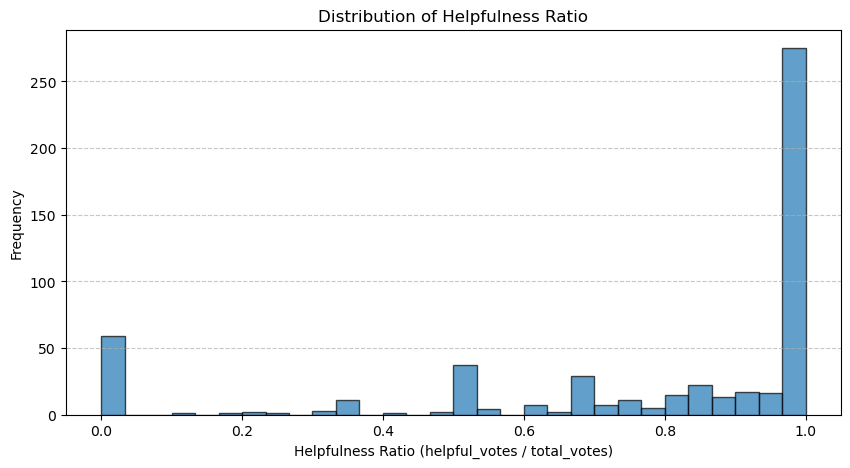

📌 The distribution of the helpfulness ratio (helpful votes divided by total votes) shows that a significant number of reviews have a ratio of 1.0, meaning they were marked as fully helpful. Additionally, there is a notable presence of reviews with a 0.0 ratio, indicating that no one found them helpful. The distribution of usefulness ratios is polarized. 
📌 Suggestion: 1. Encourage users to engage with comments and increase the 'like rate' of helpful comments, such as adding 'Was this comment helpful to you?' 2. Improve the visibility of valuable reviews, increase the weight of recommendations and improve the convenience of purchasing decisions for users.


In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Step 3: Analyze helpfulness scores and compute helpfulness ratio

# Extract helpful votes
df['helpful_votes'] = df['helpful'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else np.nan)
df['total_votes'] = df['helpful'].apply(lambda x: x[1] if isinstance(x, list) and len(x) > 1 else np.nan)

# Compute helpfulness ratio (avoid division by zero)
df['helpfulness_ratio'] = np.where(df['total_votes'] > 0, df['helpful_votes'] / df['total_votes'], np.nan)

# Plot the distribution of helpfulness ratio
plt.figure(figsize=(10, 5))
plt.hist(df['helpfulness_ratio'].dropna(), bins=30, edgecolor='black', alpha=0.7)
plt.xlabel("Helpfulness Ratio (helpful_votes / total_votes)")
plt.ylabel("Frequency")
plt.title("Distribution of Helpfulness Ratio")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

print("📌 The distribution of the helpfulness ratio (helpful votes divided by total votes) shows that a significant number of reviews have a ratio of 1.0, meaning they were marked as fully helpful. Additionally, there is a notable presence of reviews with a 0.0 ratio, indicating that no one found them helpful. The distribution of usefulness ratios is polarized. ")

print("📌 Suggestion: 1. Encourage users to engage with comments and increase the 'like rate' of helpful comments, such as adding 'Was this comment helpful to you?' 2. Improve the visibility of valuable reviews, increase the weight of recommendations and improve the convenience of purchasing decisions for users.")

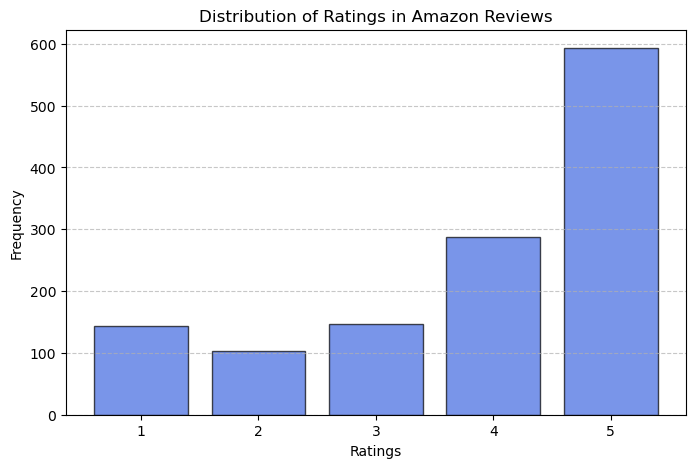

📌 The bar chart shows that the majority of reviews have high ratings (4 and 5 stars), indicating a general positive sentiment towards the products. However, there are also a significant number of 1-star reviews, suggesting some dissatisfaction.
📌 Suggestion: Further analyze the content of 1-star reviews to understand the specific reasons for user dissatisfaction and optimize the product or after-sales service. Focus on promoting high-score products to enhance market competitiveness.


In [40]:
# Step 4: Plot the frequency of ratings using a bar chart

# Count the occurrences of each rating
rating_counts = df['overall'].value_counts().sort_index()

# Plot the rating distribution
plt.figure(figsize=(8, 5))
plt.bar(rating_counts.index, rating_counts.values, color='royalblue', edgecolor='black', alpha=0.7)
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.title("Distribution of Ratings in Amazon Reviews")
plt.xticks(ticks=rating_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

print("📌 The bar chart shows that the majority of reviews have high ratings (4 and 5 stars), indicating a general positive sentiment towards the products. However, there are also a significant number of 1-star reviews, suggesting some dissatisfaction.")
print("📌 Suggestion: Further analyze the content of 1-star reviews to understand the specific reasons for user dissatisfaction and optimize the product or after-sales service. Focus on promoting high-score products to enhance market competitiveness.")


In [41]:
# Step 5: Convert unixReviewTime to a human-readable format

df['reviewDate'] = pd.to_datetime(df['unixReviewTime'], unit='s')

# Display the updated dataset with human-readable date
print(df[['reviewTime', 'unixReviewTime', 'reviewDate']].head(10))

print("Three different formats to store time data. 📌 reviewTime: Date stored as a string (text format). 📌 unixReviewTime: Date stored as Unix timestamp (integer). 📌 reviewDate: Date converted to a Pandas DateTime format.")


    reviewTime  unixReviewTime reviewDate
0  05 21, 2014      1400630400 2014-05-21
1  01 14, 2014      1389657600 2014-01-14
2  06 26, 2014      1403740800 2014-06-26
3  10 21, 2013      1382313600 2013-10-21
4   02 3, 2013      1359849600 2013-02-03
5  10 12, 2013      1381536000 2013-10-12
6  08 22, 2013      1377129600 2013-08-22
7  11 21, 2013      1384992000 2013-11-21
8  09 25, 2013      1380067200 2013-09-25
9   04 3, 2014      1396483200 2014-04-03
Three different formats to store time data. 📌 reviewTime: Date stored as a string (text format). 📌 unixReviewTime: Date stored as Unix timestamp (integer). 📌 reviewDate: Date converted to a Pandas DateTime format.


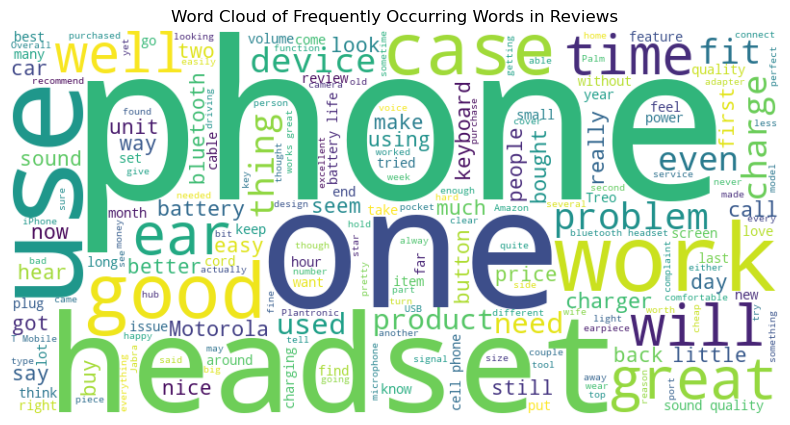

📌 The word cloud shows that common words in the reviews include "phone", "use", "headset", "case", "good", "work", and "charger", indicating key aspects users frequently discuss. That is, users are most concerned about the functionality and compatibility of accessories.


In [42]:
from wordcloud import WordCloud
# Step 6: Generate a word cloud for frequently occurring words in review text

# Combine all review texts into one string
text = " ".join(df['reviewText'].dropna())

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of Frequently Occurring Words in Reviews")
plt.show()


print("📌 The word cloud shows that common words in the reviews include \"phone\", \"use\", \"headset\", \"case\", \"good\", \"work\", and \"charger\", indicating key aspects users frequently discuss. That is, users are most concerned about the functionality and compatibility of accessories.")

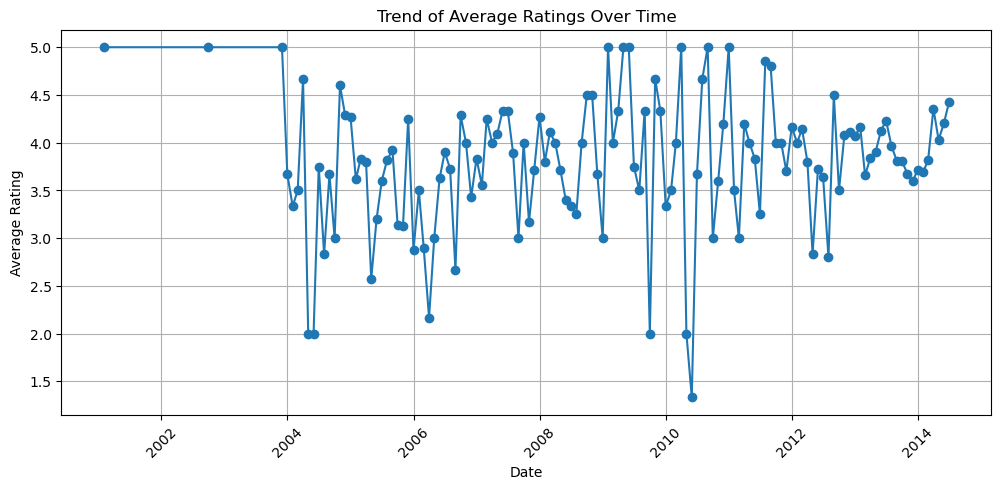

📌 The time-series graph shows fluctuations in average ratings over time, with periods of high ratings (close to 5) and occasional drops in ratings. This could indicate variations in product quality or changes in customer expectations.
📌 Suggestion: 1.Monitor reviews during periods of low ratings to see if they are related to batch issues, market competition, pricing strategies, or promotions. 2.In the period of high user satisfaction, launch marketing campaigns to enhance brand loyalty.


In [43]:
# Step 7: Plot time-series graph for average ratings over time

# Aggregate the average rating per month
df['reviewMonth'] = df['reviewDate'].dt.to_period('M')
avg_ratings_over_time = df.groupby('reviewMonth')['overall'].mean()

# Convert period index to datetime for plotting
avg_ratings_over_time.index = avg_ratings_over_time.index.to_timestamp()

# Plot the time-series graph
plt.figure(figsize=(12, 5))
plt.plot(avg_ratings_over_time.index, avg_ratings_over_time.values, marker='o', linestyle='-')
plt.xlabel("Date")
plt.ylabel("Average Rating")
plt.title("Trend of Average Ratings Over Time")
plt.xticks(rotation=45)
plt.grid(True)

# Show the plot
plt.show()

print("📌 The time-series graph shows fluctuations in average ratings over time, with periods of high ratings (close to 5) and occasional drops in ratings. This could indicate variations in product quality or changes in customer expectations.")
print("📌 Suggestion: 1.Monitor reviews during periods of low ratings to see if they are related to batch issues, market competition, pricing strategies, or promotions. 2.In the period of high user satisfaction, launch marketing campaigns to enhance brand loyalty.")


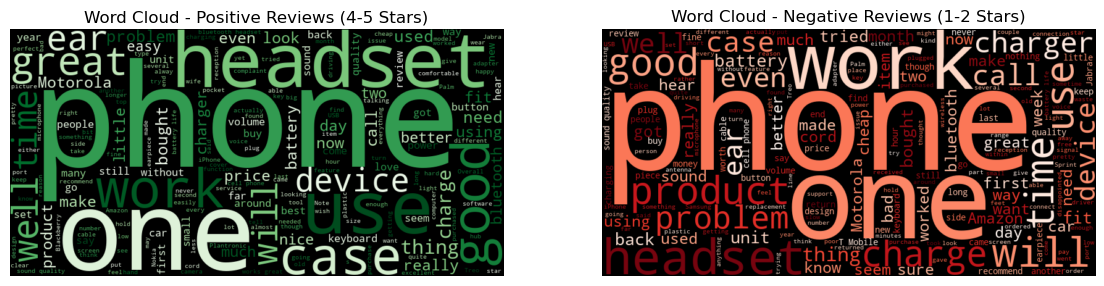

📌 Compare common words used in different sentiment categories.
📌 Possitive: Users focus on functionality, ease of use, and compatibility in positive reviews. For example, the charger works well, the headphones sound clear, and the device is easy to connect.
📌 Suggestions: 1. Analyze reasons for return and strengthen the quality inspection, ensure that the factory headphones, chargers and other accessories through the durability test, reduce product damage problems. 2. Provide more detailed product descriptions and online support to ensure that users understand the true material and performance of the product so that help users to solve problems and avoid returns due to misunderstandings.
📌 Negative: The negative feedback from users is mainly focused on product quality and durability, such as the headset is easily damaged, the charger is not durable, and the Bluetooth device cannot be connected properly.
📌 Suggestions: 1. Extract keywords from positive reviews, which is used in marketin

In [44]:
# Step 8: Generate word clouds for positive and negative reviews

# Separate positive and negative reviews
positive_reviews = " ".join(df[df['overall'] >= 4]['reviewText'].dropna())
negative_reviews = " ".join(df[df['overall'] <= 2]['reviewText'].dropna())

# Generate word clouds
wordcloud_positive = WordCloud(width=800, height=400, background_color='black', colormap='Greens').generate(positive_reviews)
wordcloud_negative = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_reviews)

# Plot the word clouds
plt.figure(figsize=(14, 6))

# Positive reviews word cloud
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Positive Reviews (4-5 Stars)")

# Negative reviews word cloud
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud - Negative Reviews (1-2 Stars)")

# Show the plots
plt.show()

print("📌 Compare common words used in different sentiment categories.")
print("📌 Possitive: Users focus on functionality, ease of use, and compatibility in positive reviews. For example, the charger works well, the headphones sound clear, and the device is easy to connect.")
print("📌 Suggestions: 1. Analyze reasons for return and strengthen the quality inspection, ensure that the factory headphones, chargers and other accessories through the durability test, reduce product damage problems. 2. Provide more detailed product descriptions and online support to ensure that users understand the true material and performance of the product so that help users to solve problems and avoid returns due to misunderstandings.")
print("📌 Negative: The negative feedback from users is mainly focused on product quality and durability, such as the headset is easily damaged, the charger is not durable, and the Bluetooth device cannot be connected properly.")
print("📌 Suggestions: 1. Extract keywords from positive reviews, which is used in marketing advertising and product description to enhance brand credibility. 2. Encourage users to leave high-quality reviews, such as offering coupons or point rewards, so that more consumers know about the benefits of the product.")

In [45]:
# Use Naive Bayes and SVM models to classify the sentiment in the Amazon customer reviews.

# Step 1: Re-import necessary libraries after execution state reset
import pandas as pd
import numpy as np
import re
import json
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Step 2: Load dataset (Ensure file exists and loads correctly)
file_path = "Amazon_Cell_Phones_and_Accessories.json"

# Read JSON file line by line (JSON Lines format)
data = []
with open(file_path, "r") as file:
    for line in file:
        try:
            data.append(json.loads(line))
        except json.JSONDecodeError:
            continue  # Skip problematic lines

# Convert the data into a DataFrame
df = pd.DataFrame(data)

# Step 3: Check if 'reviewText' column exists
if 'reviewText' not in df.columns:
    raise KeyError("The column 'reviewText' is missing from the dataset. Please check the dataset structure.")

# Step 4: Preprocess text (Create 'cleaned_review' column)
def preprocess_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

df = df.dropna(subset=['reviewText'])  # Remove rows with missing reviews
df['cleaned_review'] = df['reviewText'].apply(preprocess_text)

# Step 5: Generate sentiment labels
df['Sentiment'] = df['reviewText'].apply(lambda x: "Neutral" if pd.isna(x) else 
                                         ("Positive" if TextBlob(x).sentiment.polarity > 0 else 
                                          ("Negative" if TextBlob(x).sentiment.polarity < 0 else "Neutral")))

# Step 6: Check if 'cleaned_review' is created properly
if 'cleaned_review' not in df.columns:
    raise KeyError("The 'cleaned_review' column was not created. Check the preprocessing step.")

# Step 7: Encode sentiment labels
label_encoder = LabelEncoder()
df['Sentiment_Label'] = label_encoder.fit_transform(df['Sentiment'])

# Step 8: Split data into training and testing sets
X = df['cleaned_review']
y = df['Sentiment_Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 9: Implement Naive Bayes Model
nb_pipeline = make_pipeline(TfidfVectorizer(), MultinomialNB())
nb_pipeline.fit(X_train, y_train)
y_pred_nb = nb_pipeline.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

# Step 10: Implement SVM Model
svm_pipeline = make_pipeline(TfidfVectorizer(), SVC(kernel='linear'))
svm_pipeline.fit(X_train, y_train)
y_pred_svm = svm_pipeline.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# Step 11: Compare Model Performance
model_comparison_df = pd.DataFrame({
    "Model": ["Naive Bayes", "SVM"],
    "Accuracy": [accuracy_nb, accuracy_svm]
})

# Step 12: Display Results
print(model_comparison_df)


         Model  Accuracy
0  Naive Bayes  0.882353
1          SVM  0.886275
